# EDA 01 — Raw Google Analytics Sessions Inspection

## Objective

This notebook explores the raw Google Analytics sample sessions data extracted from BigQuery in order to:

- understand dataset grain and schema
- inspect data quality and sparsity
- evaluate which fields are useful for downstream analytics
- identify a sensible default column set for the reusable extractor
- separate default fields from optional preset fields such as marketing, device, geo, and commerce

This is a **source data understanding notebook**, not the final analysis notebook.

In [39]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery

In [40]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

In [46]:
GCP_PROJECT_ID = "data-science-portfolio-489510"
BQ_SOURCE_TABLE = "bigquery-public-data.google_analytics_sample.ga_sessions_*"

client = bigquery.Client(project=GCP_PROJECT_ID)

print("BigQuery client initialized successfully.")
print("Project:", GCP_PROJECT_ID)
print("Source table:", BQ_SOURCE_TABLE)

BigQuery client initialized successfully.
Project: data-science-portfolio-489510
Source table: bigquery-public-data.google_analytics_sample.ga_sessions_*


In [53]:
START_DATE = "20170801"
END_DATE = "20170807"
ROW_LIMIT = 50000

raw_inspection_query = f"""
SELECT
  CAST(PARSE_DATE('%Y%m%d', date) AS STRING) AS session_date,
  TIMESTAMP_SECONDS(visitStartTime) AS session_start_ts,
  fullVisitorId AS user_id,
  visitId AS session_id,
  visitNumber AS visit_number,
  channelGrouping AS channel_grouping,
  device.deviceCategory AS device_category,
  device.isMobile AS is_mobile,
  device.browser AS browser,
  device.operatingSystem AS operating_system,
  device.language AS device_language,
  geoNetwork.continent AS continent,
  geoNetwork.subContinent AS subcontinent,
  geoNetwork.country AS country,
  geoNetwork.region AS region,
  geoNetwork.city AS city,
  geoNetwork.networkDomain AS network_domain,
  trafficSource.source AS traffic_source,
  trafficSource.medium AS traffic_medium,
  trafficSource.campaign AS campaign,
  trafficSource.keyword AS keyword,
  trafficSource.adContent AS ad_content,
  totals.visits AS visits,
  totals.hits AS hits,
  totals.pageviews AS pageviews,
  totals.timeOnSite AS time_on_site,
  totals.bounces AS bounces,
  totals.newVisits AS new_visits,
  totals.transactions AS transactions,
  totals.totalTransactionRevenue / 1000000 AS revenue
FROM `{BQ_SOURCE_TABLE}`
WHERE _TABLE_SUFFIX BETWEEN '{START_DATE}' AND '{END_DATE}'
LIMIT {ROW_LIMIT}
""".strip()

print(raw_inspection_query)

SELECT
  CAST(PARSE_DATE('%Y%m%d', date) AS STRING) AS session_date,
  TIMESTAMP_SECONDS(visitStartTime) AS session_start_ts,
  fullVisitorId AS user_id,
  visitId AS session_id,
  visitNumber AS visit_number,
  channelGrouping AS channel_grouping,
  device.deviceCategory AS device_category,
  device.isMobile AS is_mobile,
  device.browser AS browser,
  device.operatingSystem AS operating_system,
  device.language AS device_language,
  geoNetwork.continent AS continent,
  geoNetwork.subContinent AS subcontinent,
  geoNetwork.country AS country,
  geoNetwork.region AS region,
  geoNetwork.city AS city,
  geoNetwork.networkDomain AS network_domain,
  trafficSource.source AS traffic_source,
  trafficSource.medium AS traffic_medium,
  trafficSource.campaign AS campaign,
  trafficSource.keyword AS keyword,
  trafficSource.adContent AS ad_content,
  totals.visits AS visits,
  totals.hits AS hits,
  totals.pageviews AS pageviews,
  totals.timeOnSite AS time_on_site,
  totals.bounces AS bounce

## 1. Load raw  data

The goal here is to inspect the raw extraction generated from BigQuery before finalizing the extractor design.

In [54]:
df = client.query(raw_inspection_query).to_dataframe()

print("Shape:", df.shape)
df.head()

Shape: (2556, 30)


,session_date,session_start_ts,user_id,session_id,visit_number,channel_grouping,device_category,is_mobile,browser,operating_system,device_language,continent,subcontinent,country,region,city,network_domain,traffic_source,traffic_medium,campaign,keyword,ad_content,visits,hits,pageviews,time_on_site,bounces,new_visits,transactions,revenue
0,2017-08-01,2017-08-01 12:46:08+00:00,3418334011779872055,1501591568,1,Organic Search,desktop,False,Chrome,Windows,not available in demo dataset,Europe,Southern Europe,Greece,not available in demo dataset,not available in demo dataset,tellas.gr,(direct),(none),(not set),None,None,1,1,1,<NA>,1,1,<NA>,NaN
1,2017-08-01,2017-08-01 12:14:07+00:00,2474397855041322408,1501589647,2,Referral,desktop,False,Chrome,Windows,not available in demo dataset,Asia,Southern Asia,India,Maharashtra,Mumbai,unknown.unknown,analytics.google.com,referral,(not set),None,None,1,1,1,<NA>,1,<NA>,<NA>,NaN
2,2017-08-01,2017-08-01 19:43:41+00:00,5870462820713110108,1501616621,1,Referral,desktop,False,Chrome,Windows,not available in demo dataset,Europe,Northern Europe,United Kingdom,not available in demo dataset,not available in demo dataset,as9105.com,analytics.google.com,referral,(not set),None,None,1,1,1,<NA>,1,1,<NA>,NaN
3,2017-08-01,2017-08-01 15:26:40+00:00,9397809171349480379,1501601200,1,Referral,desktop,False,Firefox,Windows,not available in demo dataset,Americas,Northern America,United States,Texas,Dallas,h5colo.com,analytics.google.com,referral,(not set),None,None,1,1,1,<NA>,1,1,<NA>,NaN
4,2017-08-01,2017-08-01 19:25:25+00:00,6089902943184578335,1501615525,1,Referral,desktop,False,Chrome,Windows,not available in demo dataset,Americas,Northern America,United States,not available in demo dataset,not available in demo dataset,(not set),adwords.google.com,referral,(not set),None,None,1,1,1,<NA>,1,1,<NA>,NaN


## 2. Initial structural inspection

Start with a basic inspection of:
- number of rows and columns
- data types
- a high-level schema summary

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2556 entries, 0 to 2555
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   session_date      2556 non-null   object             
 1   session_start_ts  2556 non-null   datetime64[us, UTC]
 2   user_id           2556 non-null   object             
 3   session_id        2556 non-null   Int64              
 4   visit_number      2556 non-null   Int64              
 5   channel_grouping  2556 non-null   object             
 6   device_category   2556 non-null   object             
 7   is_mobile         2556 non-null   boolean            
 8   browser           2556 non-null   object             
 9   operating_system  2556 non-null   object             
 10  device_language   2556 non-null   object             
 11  continent         2556 non-null   object             
 12  subcontinent      2556 non-null   object             
 13  cou

In [56]:
schema_df = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(dtype) for dtype in df.dtypes],
        "non_null_count": df.notna().sum().values,
        "null_count": df.isna().sum().values,
        "null_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": [df[col].nunique(dropna=True) for col in df.columns],
    }
).sort_values(["null_pct", "column"], ascending=[False, True])

schema_df

,column,dtype,non_null_count,null_count,null_pct,n_unique
20,keyword,object,5,2551,99.80,3
21,ad_content,object,12,2544,99.53,2
29,revenue,float64,43,2513,98.32,43
28,transactions,Int64,43,2513,98.32,2
26,bounces,Int64,1238,1318,51.56,1
25,time_on_site,Int64,1310,1246,48.75,550
27,new_visits,Int64,1872,684,26.76,1
8,browser,object,2556,0,0.00,15
19,campaign,object,2556,0,0.00,2
5,channel_grouping,object,2556,0,0.00,7


In [58]:
schema_df.sort_values("null_pct", ascending=False).head(20)

,column,dtype,non_null_count,null_count,null_pct,n_unique
20,keyword,object,5,2551,99.80,3
21,ad_content,object,12,2544,99.53,2
29,revenue,float64,43,2513,98.32,43
28,transactions,Int64,43,2513,98.32,2
26,bounces,Int64,1238,1318,51.56,1
25,time_on_site,Int64,1310,1246,48.75,550
27,new_visits,Int64,1872,684,26.76,1
8,browser,object,2556,0,0.00,15
19,campaign,object,2556,0,0.00,2
5,channel_grouping,object,2556,0,0.00,7


### Initial observations

At this point, focus on:
- which columns are mostly complete
- which columns are sparse
- which columns appear highly cardinal
- whether the extracted schema already looks usable for product / marketing analytics

## 3. Basic descriptive summary

Inspect numeric distributions and candidate categorical fields to understand the overall structure of the dataset.

In [59]:
numeric_summary = df.describe(include=[np.number]).T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
session_id,2556.0,1501614428.081768,22804.553787,1501570398.0,1501596985.75,1501614013.5,1501631919.0,1501657193.0
visit_number,2556.0,2.661189,12.0222,1.0,1.0,1.0,2.0,326.0
visits,2556.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
hits,2556.0,5.17723,11.816349,1.0,1.0,2.0,5.0,302.0
pageviews,2556.0,4.279734,7.966343,1.0,1.0,2.0,4.0,155.0
time_on_site,1310.0,325.051908,592.411724,1.0,32.0,96.5,336.75,5455.0
bounces,1238.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
new_visits,1872.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
transactions,43.0,1.046512,0.213083,1.0,1.0,1.0,1.0,2.0
revenue,43.0,206.744186,478.524665,2.99,34.395,50.79,169.52,2935.61


In [60]:
categorical_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
categorical_cols, len(categorical_cols)

(['session_date',
  'user_id',
  'channel_grouping',
  'device_category',
  'is_mobile',
  'browser',
  'operating_system',
  'device_language',
  'continent',
  'subcontinent',
  'country',
  'region',
  'city',
  'network_domain',
  'traffic_source',
  'traffic_medium',
  'campaign',
  'keyword',
  'ad_content'],
 19)

## 4. Grain and key checks

A key part of the first EDA is validating the dataset grain.

Questions to inspect:
- Is one row equal to one session?
- Is `session_id` unique enough on its own?
- Is the pair `user_id + session_id` a better session identifier?
- Does `user_id + visit_number` also behave like a unique session key?

In [61]:
key_candidates = [col for col in ["user_id", "session_id", "visit_number", "session_date"] if col in df.columns]
df[key_candidates].head()

,user_id,session_id,visit_number,session_date
0,3418334011779872055,1501591568,1,2017-08-01
1,2474397855041322408,1501589647,2,2017-08-01
2,5870462820713110108,1501616621,1,2017-08-01
3,9397809171349480379,1501601200,1,2017-08-01
4,6089902943184578335,1501615525,1,2017-08-01


In [62]:
grain_checks = {}

if "session_id" in df.columns:
    grain_checks["session_id_unique_rows_pct"] = round(
        df["session_id"].nunique(dropna=True) / len(df) * 100, 2
    )

if {"user_id", "session_id"}.issubset(df.columns):
    grain_checks["user_id_session_id_unique_rows_pct"] = round(
        df[["user_id", "session_id"]].drop_duplicates().shape[0] / len(df) * 100, 2
    )

if {"user_id", "visit_number"}.issubset(df.columns):
    grain_checks["user_id_visit_number_unique_rows_pct"] = round(
        df[["user_id", "visit_number"]].drop_duplicates().shape[0] / len(df) * 100, 2
    )

pd.Series(grain_checks, name="value")

session_id_unique_rows_pct               98.16
user_id_session_id_unique_rows_pct      100.00
user_id_visit_number_unique_rows_pct    100.00
Name: value, dtype: float64

In [63]:
grain_checks = {}

if "session_id" in df.columns:
    grain_checks["session_id_unique_rows_pct"] = round(
        df["session_id"].nunique(dropna=True) / len(df) * 100, 2
    )

if {"user_id", "session_id"}.issubset(df.columns):
    grain_checks["user_id_session_id_unique_rows_pct"] = round(
        df[["user_id", "session_id"]].drop_duplicates().shape[0] / len(df) * 100, 2
    )

if {"user_id", "visit_number"}.issubset(df.columns):
    grain_checks["user_id_visit_number_unique_rows_pct"] = round(
        df[["user_id", "visit_number"]].drop_duplicates().shape[0] / len(df) * 100, 2
    )

pd.Series(grain_checks, name="value")

session_id_unique_rows_pct               98.16
user_id_session_id_unique_rows_pct      100.00
user_id_visit_number_unique_rows_pct    100.00
Name: value, dtype: float64

### Grain decision notes

If `user_id + session_id` is effectively unique across rows, that supports treating the dataset as session-level data.

This is useful for the extractor because it confirms whether the selected fields align with the intended session grain.

## 5. Date handling and temporal coverage

Inspect the extracted date field and understand the time coverage of the dataset.

In [64]:
if "session_date" in df.columns:
    df["session_date"] = pd.to_datetime(df["session_date"], errors="coerce")

df[["session_date"]].head()

,session_date
0,2017-08-01
1,2017-08-01
2,2017-08-01
3,2017-08-01
4,2017-08-01


In [65]:
if "session_date" in df.columns:
    date_summary = pd.Series(
        {
            "min_date": df["session_date"].min(),
            "max_date": df["session_date"].max(),
            "n_unique_dates": df["session_date"].nunique(dropna=True),
            "null_pct": round(df["session_date"].isna().mean() * 100, 2),
        }
    )
    date_summary
else:
    print("session_date column not available.")

In [66]:
if "session_date" in df.columns:
    daily_sessions = (
        df.groupby("session_date")
        .size()
        .rename("sessions")
        .reset_index()
        .sort_values("session_date")
    )
    daily_sessions.head()
else:
    print("session_date column not available.")

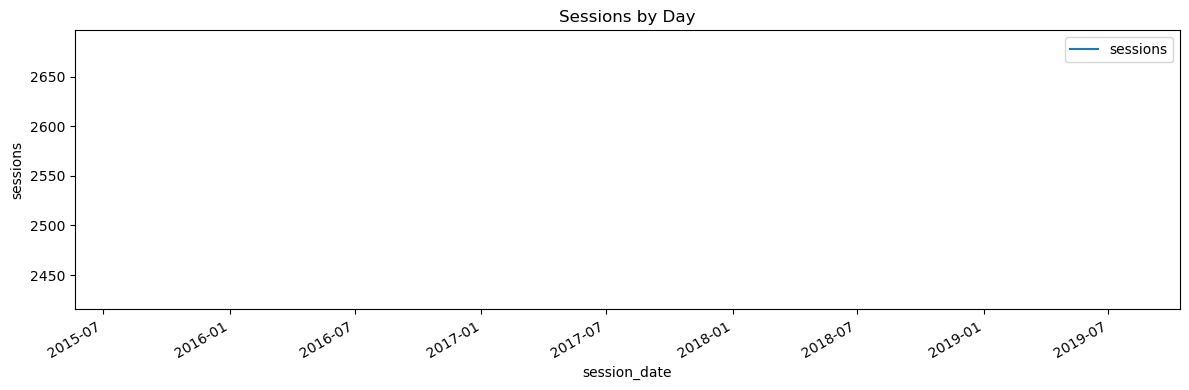

In [67]:
if "session_date" in df.columns:
    daily_sessions.plot(
        x="session_date",
        y="sessions",
        figsize=(12, 4),
        title="Sessions by Day"
    )
    plt.xlabel("session_date")
    plt.ylabel("sessions")
    plt.tight_layout()
    plt.show()

## 6. Candidate dimensions review

This section reviews likely dimension fields for the extractor, including:
- acquisition fields
- device fields
- geo fields
- traffic grouping fields

The goal is not only to inspect them, but also to decide whether they belong in:
- the default extractor column set
- an optional preset
- or should be excluded initially

In [68]:
candidate_dimension_cols = [
    col
    for col in [
        "channel_grouping",
        "device_category",
        "is_mobile",
        "browser",
        "operating_system",
        "device_language",
        "continent",
        "subcontinent",
        "country",
        "region",
        "city",
        "network_domain",
        "traffic_source",
        "traffic_medium",
        "campaign",
        "keyword",
        "ad_content",
    ]
    if col in df.columns
]

candidate_dimension_cols

['channel_grouping',
 'device_category',
 'is_mobile',
 'browser',
 'operating_system',
 'device_language',
 'continent',
 'subcontinent',
 'country',
 'region',
 'city',
 'network_domain',
 'traffic_source',
 'traffic_medium',
 'campaign',
 'keyword',
 'ad_content']

In [69]:
dimension_profile = pd.DataFrame(
    {
        "column": candidate_dimension_cols,
        "non_null_count": [df[col].notna().sum() for col in candidate_dimension_cols],
        "null_pct": [(df[col].isna().mean() * 100).round(2) for col in candidate_dimension_cols],
        "n_unique": [df[col].nunique(dropna=True) for col in candidate_dimension_cols],
        "top_value": [
            df[col].mode(dropna=True).iloc[0] if df[col].notna().any() else None
            for col in candidate_dimension_cols
        ],
        "top_value_pct": [
            round(df[col].value_counts(normalize=True, dropna=True).iloc[0] * 100, 2)
            if df[col].notna().any()
            else None
            for col in candidate_dimension_cols
        ],
    }
).sort_values(["null_pct", "n_unique"], ascending=[False, False])

dimension_profile

,column,non_null_count,null_pct,n_unique,top_value,top_value_pct
15,keyword,5,99.80,3,(not provided),60.00
16,ad_content,12,99.53,2,Display Ad created 3/11/14,91.67
11,network_domain,2556,0.00,524,(not set),39.24
8,country,2556,0.00,94,United States,50.35
10,city,2556,0.00,56,not available in demo dataset,54.30
9,region,2556,0.00,42,not available in demo dataset,54.30
12,traffic_source,2556,0.00,35,(direct),84.74
7,subcontinent,2556,0.00,19,Northern America,53.68
3,browser,2556,0.00,15,Chrome,74.33
4,operating_system,2556,0.00,9,Windows,32.63


In [70]:
for col in candidate_dimension_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts(dropna=False).head(15))


===== channel_grouping =====
channel_grouping
Organic Search    1346
Referral           436
Direct             400
Social             213
Paid Search         70
Affiliates          52
Display             39
Name: count, dtype: int64

===== device_category =====
device_category
desktop    1742
mobile      725
tablet       89
Name: count, dtype: int64

===== is_mobile =====
is_mobile
False    1741
True      815
Name: count, dtype: Int64

===== browser =====
browser
Chrome                      1900
Safari                       397
Firefox                      101
Internet Explorer             54
Edge                          23
Opera Mini                    21
Android Webview               19
Opera                         16
Safari (in-app)               10
UC Browser                     6
Coc Coc                        2
Nokia Browser                  2
Android Browser                2
YaBrowser                      2
Mozilla Compatible Agent       1
Name: count, dtype: int64

===== ope

### Dimension review notes

Useful questions:
- Is the field broadly populated?
- Is it too sparse for the default set?
- Is it business-relevant even if sparse?
- Does it feel like a core field or a drill-down field?

For example:
- `traffic_source`, `traffic_medium`, `campaign` usually have high analytical value
- `keyword` and `ad_content` may be useful but more optional
- `city` and `network_domain` may be helpful, but not always essential in the first default extraction

## 7. Candidate measures review

Now inspect the core measure columns to understand:
- sparsity
- zero-heavy behavior
- skewness
- suitability for the default extraction

In [71]:
candidate_measure_cols = [
    col
    for col in [
        "visits",
        "hits",
        "pageviews",
        "time_on_site",
        "bounces",
        "new_visits",
        "transactions",
        "revenue",
    ]
    if col in df.columns
]

candidate_measure_cols

['visits',
 'hits',
 'pageviews',
 'time_on_site',
 'bounces',
 'new_visits',
 'transactions',
 'revenue']

In [72]:
measure_profile = pd.DataFrame(
    {
        "column": candidate_measure_cols,
        "non_null_count": [df[col].notna().sum() for col in candidate_measure_cols],
        "null_pct": [(df[col].isna().mean() * 100).round(2) for col in candidate_measure_cols],
        "mean": [df[col].mean() for col in candidate_measure_cols],
        "median": [df[col].median() for col in candidate_measure_cols],
        "p95": [df[col].quantile(0.95) for col in candidate_measure_cols],
        "max": [df[col].max() for col in candidate_measure_cols],
        "zero_pct": [
            round(((df[col].fillna(0) == 0).mean() * 100), 2)
            for col in candidate_measure_cols
        ],
    }
).sort_values("null_pct", ascending=False)

measure_profile

,column,non_null_count,null_pct,mean,median,p95,max,zero_pct
6,transactions,43,98.32,1.046512,1.00,1.000,2.00,98.32
7,revenue,43,98.32,206.744186,50.79,927.778,2935.61,98.32
4,bounces,1238,51.56,1.000000,1.00,1.000,1.00,51.56
3,time_on_site,1310,48.75,325.051908,96.50,1414.550,5455.00,48.75
5,new_visits,1872,26.76,1.000000,1.00,1.000,1.00,26.76
2,pageviews,2556,0.00,4.279734,2.00,17.000,155.00,0.00
0,visits,2556,0.00,1.000000,1.00,1.000,1.00,0.00
1,hits,2556,0.00,5.177230,2.00,21.000,302.00,0.00


In [73]:
measure_profile = pd.DataFrame(
    {
        "column": candidate_measure_cols,
        "non_null_count": [df[col].notna().sum() for col in candidate_measure_cols],
        "null_pct": [(df[col].isna().mean() * 100).round(2) for col in candidate_measure_cols],
        "mean": [df[col].mean() for col in candidate_measure_cols],
        "median": [df[col].median() for col in candidate_measure_cols],
        "p95": [df[col].quantile(0.95) for col in candidate_measure_cols],
        "max": [df[col].max() for col in candidate_measure_cols],
        "zero_pct": [
            round(((df[col].fillna(0) == 0).mean() * 100), 2)
            for col in candidate_measure_cols
        ],
    }
).sort_values("null_pct", ascending=False)

measure_profile

,column,non_null_count,null_pct,mean,median,p95,max,zero_pct
6,transactions,43,98.32,1.046512,1.00,1.000,2.00,98.32
7,revenue,43,98.32,206.744186,50.79,927.778,2935.61,98.32
4,bounces,1238,51.56,1.000000,1.00,1.000,1.00,51.56
3,time_on_site,1310,48.75,325.051908,96.50,1414.550,5455.00,48.75
5,new_visits,1872,26.76,1.000000,1.00,1.000,1.00,26.76
2,pageviews,2556,0.00,4.279734,2.00,17.000,155.00,0.00
0,visits,2556,0.00,1.000000,1.00,1.000,1.00,0.00
1,hits,2556,0.00,5.177230,2.00,21.000,302.00,0.00


### Measure review notes

Important interpretation points:
- `transactions` and `revenue` may be sparse but still critical
- `hits`, `pageviews`, and `time_on_site` are usually strong engagement measures
- `bounces` may be very useful even if partially null depending on extraction behavior
- `new_visits` may be useful but not necessarily essential for the default extractor

## 8. Build a column decision table

This is the most important section for the extractor design.

The idea is to turn the EDA into explicit schema decisions:
- include in default extractor
- assign to a preset
- exclude for now
- document the reason

In [74]:
business_relevance = {
    "session_date": "High",
    "session_start_ts": "High",
    "user_id": "High",
    "session_id": "High",
    "visit_number": "Medium",
    "channel_grouping": "High",
    "device_category": "High",
    "is_mobile": "High",
    "browser": "Medium",
    "operating_system": "Medium",
    "device_language": "Medium",
    "continent": "Low",
    "subcontinent": "Medium",
    "country": "High",
    "region": "Medium",
    "city": "Medium",
    "network_domain": "Low",
    "traffic_source": "High",
    "traffic_medium": "High",
    "campaign": "High",
    "keyword": "Medium",
    "ad_content": "Medium",
    "visits": "High",
    "hits": "High",
    "pageviews": "High",
    "time_on_site": "High",
    "bounces": "High",
    "new_visits": "Medium",
    "transactions": "High",
    "revenue": "High",
}

In [75]:
column_review = pd.DataFrame({"column": df.columns})

column_review["dtype"] = column_review["column"].map(lambda c: str(df[c].dtype))
column_review["null_pct"] = column_review["column"].map(lambda c: round(df[c].isna().mean() * 100, 2))
column_review["n_unique"] = column_review["column"].map(lambda c: df[c].nunique(dropna=True))
column_review["business_relevance"] = column_review["column"].map(lambda c: business_relevance.get(c, "Review"))
column_review["recommended_default"] = False
column_review["recommended_preset"] = None
column_review["notes"] = ""

column_review

,column,dtype,null_pct,n_unique,business_relevance,recommended_default,recommended_preset,notes
0,session_date,datetime64[ns],0.00,1,High,False,None,
1,session_start_ts,"datetime64[us, UTC]",0.00,2509,High,False,None,
2,user_id,object,0.00,2293,High,False,None,
3,session_id,Int64,0.00,2509,High,False,None,
4,visit_number,Int64,0.00,46,Medium,False,None,
5,channel_grouping,object,0.00,7,High,False,None,
6,device_category,object,0.00,3,High,False,None,
7,is_mobile,boolean,0.00,2,High,False,None,
8,browser,object,0.00,15,Medium,False,None,
9,operating_system,object,0.00,9,Medium,False,None,


In [76]:
default_recommended = {
    "session_date",
    "session_start_ts",
    "user_id",
    "session_id",
    "visit_number",
    "channel_grouping",
    "device_category",
    "is_mobile",
    "browser",
    "operating_system",
    "country",
    "traffic_source",
    "traffic_medium",
    "campaign",
    "visits",
    "hits",
    "pageviews",
    "time_on_site",
    "bounces",
    "transactions",
    "revenue",
}

preset_mapping = {
    "device_language": "device",
    "continent": "geo",
    "subcontinent": "geo",
    "region": "geo",
    "city": "geo",
    "network_domain": "geo",
    "keyword": "marketing",
    "ad_content": "marketing",
    "new_visits": "commerce",
}

In [77]:
column_review["recommended_default"] = column_review["column"].isin(default_recommended)
column_review["recommended_preset"] = column_review["column"].map(preset_mapping)

column_review.loc[column_review["column"] == "keyword", "notes"] = "Useful acquisition detail, but often sparse."
column_review.loc[column_review["column"] == "ad_content", "notes"] = "Useful for marketing drill-down, not essential in default set."
column_review.loc[column_review["column"] == "network_domain", "notes"] = "Potentially useful for technical segmentation, lower business priority."
column_review.loc[column_review["column"] == "city", "notes"] = "Useful for geo analysis, but not necessary in first default extraction."
column_review.loc[column_review["column"] == "revenue", "notes"] = "Critical target metric for commerce-oriented analysis."
column_review.loc[column_review["column"] == "transactions", "notes"] = "Important outcome metric despite sparsity."

column_review = column_review.sort_values(
    ["recommended_default", "business_relevance", "null_pct"],
    ascending=[False, True, True],
)

column_review

,column,dtype,null_pct,n_unique,business_relevance,recommended_default,recommended_preset,notes
0,session_date,datetime64[ns],0.00,1,High,True,NaN,
1,session_start_ts,"datetime64[us, UTC]",0.00,2509,High,True,NaN,
2,user_id,object,0.00,2293,High,True,NaN,
3,session_id,Int64,0.00,2509,High,True,NaN,
5,channel_grouping,object,0.00,7,High,True,NaN,
6,device_category,object,0.00,3,High,True,NaN,
7,is_mobile,boolean,0.00,2,High,True,NaN,
13,country,object,0.00,94,High,True,NaN,
17,traffic_source,object,0.00,35,High,True,NaN,
18,traffic_medium,object,0.00,5,High,True,NaN,


### Interpretation of the decision table

This table is the bridge between EDA and code design.

It helps answer:
- Which columns should always be extracted?
- Which columns are valuable but optional?
- Which columns are currently lower priority?

In [78]:
default_columns_final = (
    column_review.loc[column_review["recommended_default"], "column"].tolist()
)

preset_columns_final = {
    preset: column_review.loc[column_review["recommended_preset"] == preset, "column"].tolist()
    for preset in sorted(column_review["recommended_preset"].dropna().unique())
}

default_columns_final, preset_columns_final

(['session_date',
  'session_start_ts',
  'user_id',
  'session_id',
  'channel_grouping',
  'device_category',
  'is_mobile',
  'country',
  'traffic_source',
  'traffic_medium',
  'campaign',
  'visits',
  'hits',
  'pageviews',
  'time_on_site',
  'bounces',
  'transactions',
  'revenue',
  'visit_number',
  'browser',
  'operating_system'],
 {'commerce': ['new_visits'],
  'device': ['device_language'],
  'geo': ['continent', 'network_domain', 'subcontinent', 'region', 'city'],
  'marketing': ['ad_content', 'keyword']})

## 9. Generate extractor-friendly outputs

The next cells print the recommended default columns and preset columns in a format that can be copied into the extractor code.

In [79]:
print("DEFAULT_COLUMNS = [")
for col in default_columns_final:
    print(f'    "{col}",')
print("]")

DEFAULT_COLUMNS = [
    "session_date",
    "session_start_ts",
    "user_id",
    "session_id",
    "channel_grouping",
    "device_category",
    "is_mobile",
    "country",
    "traffic_source",
    "traffic_medium",
    "campaign",
    "visits",
    "hits",
    "pageviews",
    "time_on_site",
    "bounces",
    "transactions",
    "revenue",
    "visit_number",
    "browser",
    "operating_system",
]


In [80]:
for preset_name, cols in preset_columns_final.items():
    print(f'\n"{preset_name}": [')
    for col in cols:
        print(f'    "{col}",')
    print("],")


"commerce": [
    "new_visits",
],

"device": [
    "device_language",
],

"geo": [
    "continent",
    "network_domain",
    "subcontinent",
    "region",
    "city",
],

"marketing": [
    "ad_content",
    "keyword",
],


## 10. Summary of extractor design decisions

This section provides a compact summary of what the notebook recommends for the initial extraction design.

In [81]:
extractor_decision_summary = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "column_count",
            "date_min",
            "date_max",
            "default_column_count",
            "marketing_preset_count",
            "device_preset_count",
            "geo_preset_count",
            "commerce_preset_count",
        ],
        "value": [
            len(df),
            df.shape[1],
            df["session_date"].min() if "session_date" in df.columns else None,
            df["session_date"].max() if "session_date" in df.columns else None,
            len(default_columns_final),
            len(preset_columns_final.get("marketing", [])),
            len(preset_columns_final.get("device", [])),
            len(preset_columns_final.get("geo", [])),
            len(preset_columns_final.get("commerce", [])),
        ],
    }
)

extractor_decision_summary

,metric,value
0,row_count,2556
1,column_count,30
2,date_min,2017-08-01 00:00:00
3,date_max,2017-08-01 00:00:00
4,default_column_count,21
5,marketing_preset_count,2
6,device_preset_count,1
7,geo_preset_count,5
8,commerce_preset_count,1


## 11. Export review artifacts

Saving the column review table is useful because it documents the rationale behind the extractor schema and can be referenced later when refining the code.

In [82]:
OUTPUT_REVIEW_PATH = Path("../data/raw/ga_sessions_column_review.csv")
column_review.to_csv(OUTPUT_REVIEW_PATH, index=False)
print(f"Saved column review to {OUTPUT_REVIEW_PATH}")

Saved column review to ../data/raw/ga_sessions_column_review.csv


In [83]:
default_columns_final

['session_date',
 'session_start_ts',
 'user_id',
 'session_id',
 'channel_grouping',
 'device_category',
 'is_mobile',
 'country',
 'traffic_source',
 'traffic_medium',
 'campaign',
 'visits',
 'hits',
 'pageviews',
 'time_on_site',
 'bounces',
 'transactions',
 'revenue',
 'visit_number',
 'browser',
 'operating_system']

In [84]:
preset_columns_final

{'commerce': ['new_visits'],
 'device': ['device_language'],
 'geo': ['continent', 'network_domain', 'subcontinent', 'region', 'city'],
 'marketing': ['ad_content', 'keyword']}

## 12. Final notes

### Main outcome of this notebook
This notebook supports the first version of the reusable extractor by:
- validating the extracted schema
- reviewing field completeness and usefulness
- distinguishing core fields from optional fields
- documenting the rationale behind the initial default column set

### Next step
Use the recommended `DEFAULT_COLUMNS` and preset groupings to refine the extraction code in `src/`.

In [85]:
engagement_cols = [col for col in ["hits", "pageviews", "time_on_site", "bounces"] if col in df.columns]

if engagement_cols:
    df[engagement_cols].corr()
else:
    print("No engagement columns available.")

In [86]:
engagement_cols = [col for col in ["hits", "pageviews", "time_on_site", "bounces"] if col in df.columns]

if engagement_cols:
    df[engagement_cols].corr()
else:
    print("No engagement columns available.")

In [87]:
acquisition_cols = [col for col in ["traffic_source", "traffic_medium", "campaign"] if col in df.columns]

if len(acquisition_cols) == 3:
    (
        df.groupby(acquisition_cols)
        .size()
        .reset_index(name="sessions")
        .sort_values("sessions", ascending=False)
        .head(20)
    )
else:
    print("traffic_source, traffic_medium, and campaign not all available.")